# P, PI, and PID Controllers

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pid import PController, PIController, PIDController


T_END = 15.0
t = np.linspace(0, T_END, 3000)
dt = t[1] - t[0]


# ── Plant G(s) = 1/(s+1)^2 in state-space ─────────────────────────────
# x1' = x2,   x2' = -x1 - 2·x2 + u,   y = x1
def plant_step(x, u, dt):
    """Advance the plant one timestep with RK4."""

    def f(x):
        return np.array([x[1], -x[0] - 2 * x[1] + u])

    k1 = f(x)
    k2 = f(x + 0.5 * dt * k1)
    k3 = f(x + 0.5 * dt * k2)
    k4 = f(x + dt * k3)
    return x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)


def simulate(controller, t, is_pid=False):
    x, sp = np.zeros(2), 1.0
    y_out = np.empty(len(t))
    dt = t[1] - t[0]
    for i in range(len(t)):
        y = x[0]
        y_out[i] = y
        u = (
            controller.calc_input(sp, y, -1e6, 1e6)
            if is_pid
            else controller.calc_input(sp, y)
        )
        x = plant_step(x, u, dt)
    return t, y_out

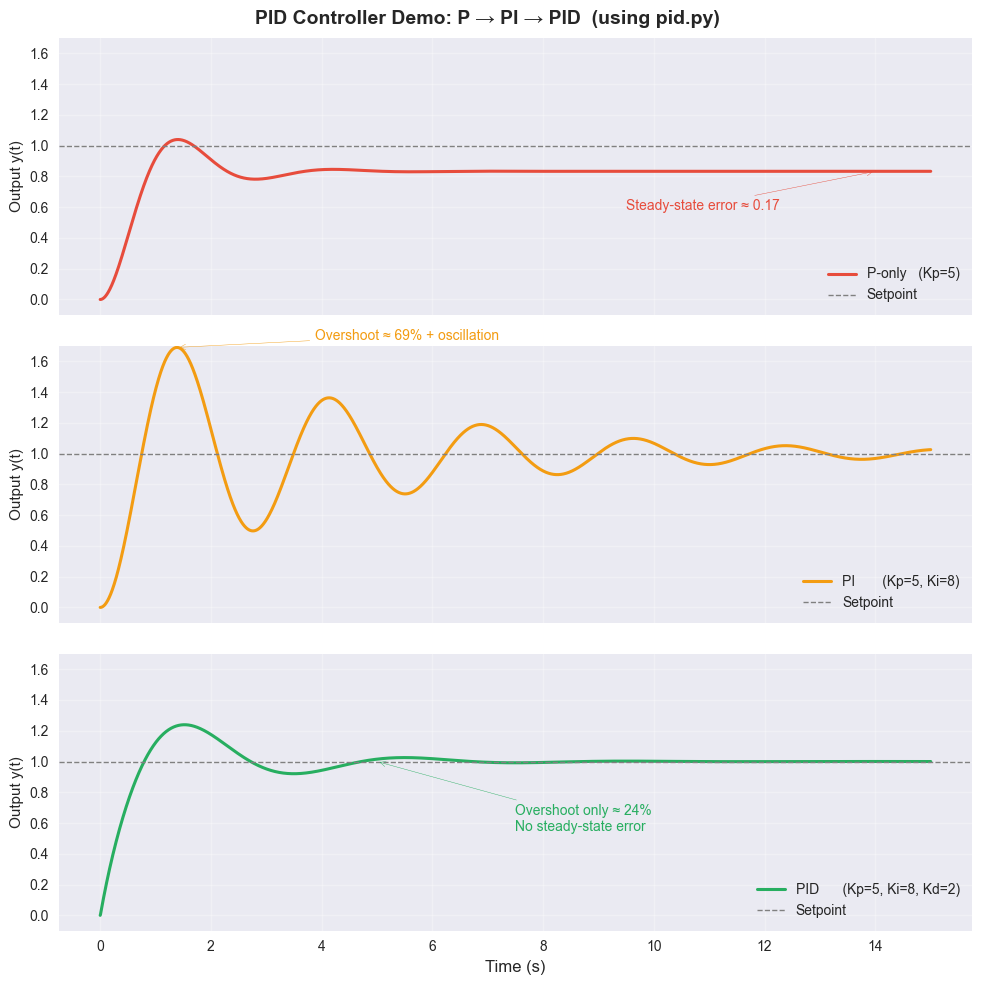

In [ ]:
# ── Controllers (gains scaled for discrete time) ───────────────────────
# Continuous gains: Kp=5, Ki=8, Kd=2
# PIController  : Ki_discrete = Ki_continuous × dt
# PIDController : Ki_discrete = Ki × dt,  Kd_discrete = Kd / dt
controllers = [
    ("P-only   (Kp=5)", PController(Kp=5.0), False),
    ("PI       (Kp=5, Ki=8)", PIController(Kp=5.0, Ki=8.0 * dt), False),
    (
        "PID      (Kp=5, Ki=8, Kd=2)",
        PIDController(Kp=5.0, Ki=8.0 * dt, Kd=2.0 / dt),
        True,
    ),
]


# ── Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
colors = ["#e74c3c", "#f39c12", "#27ae60"]

for idx, (label, ctrl, is_pid) in enumerate(controllers):
    t_out, y = simulate(ctrl, t, is_pid=is_pid)

    ax = axes[idx]
    ax.plot(t_out, y, color=colors[idx], linewidth=2.2, label=label)
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Setpoint")
    ax.set_ylabel("Output y(t)", fontsize=11)
    ax.set_ylim(-0.1, 1.7)
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(True, alpha=0.3)

    if idx == 0:
        ss = y[-1]
        ax.annotate(
            f"Steady-state error ≈ {1.0 - ss:.2f}",
            xy=(T_END - 1, ss),
            xytext=(T_END - 5.5, ss - 0.25),
            arrowprops=dict(arrowstyle="->", color=colors[idx]),
            fontsize=10,
            color=colors[idx],
        )
    elif idx == 1:
        peak, t_peak = np.max(y), t_out[np.argmax(y)]
        ax.annotate(
            f"Overshoot ≈ {(peak - 1.0) * 100:.0f}% + oscillation",
            xy=(t_peak, peak),
            xytext=(t_peak + 2.5, peak + 0.05),
            arrowprops=dict(arrowstyle="->", color=colors[idx]),
            fontsize=10,
            color=colors[idx],
        )
    else:
        peak = np.max(y)
        ax.annotate(
            f"Overshoot only ≈ {(peak - 1.0) * 100:.0f}%\nNo steady-state error",
            xy=(5, 1.0),
            xytext=(7.5, 0.55),
            arrowprops=dict(arrowstyle="->", color=colors[idx]),
            fontsize=10,
            color=colors[idx],
        )

axes[-1].set_xlabel("Time (s)", fontsize=12)
fig.suptitle(
    "PID Controller Demo: P → PI → PID  (using pid.py)", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()